# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.

In [55]:
# Import the library
import cv2 
import numpy as np
from PIL import Image , ImageOps
from skimage import data
import matplotlib.pyplot as plt #

%matplotlib inline

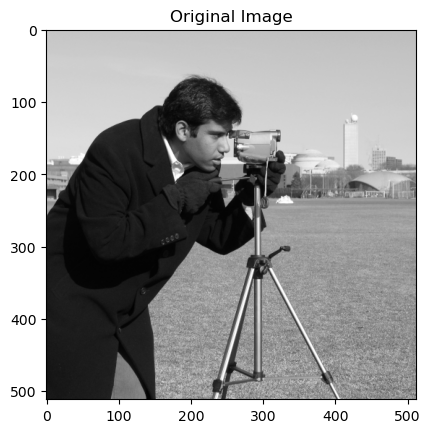

In [56]:
# ── Load image ────────────────────────────────────
img = Image.fromarray(data.camera())
plt.imshow(img , cmap = "gray")
plt.title("Original Image")
plt.show()

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [57]:
# Get the size of the image
width , height = img.size 

# scaling factors
scale = 2

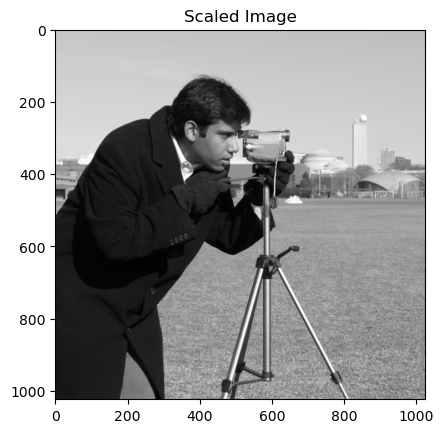

In [58]:
# ── 1. Increase size (scale ×2) 
new_width = width * scale
new_height = height * scale

# Resize the image using PIL's built-in method
scaled_image = img.resize((new_width , new_height) , Image.Resampling.LANCZOS)

plt.imshow(scaled_image , cmap = "gray")
plt.title("Scaled Image")
plt.show()

In [59]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_image.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:", scaled_image.size)

Original size: (512, 512)
Scaled size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [60]:
# Get the size of the image
width , height = img.size 

# scaling factors
cx = 2
cy = 1

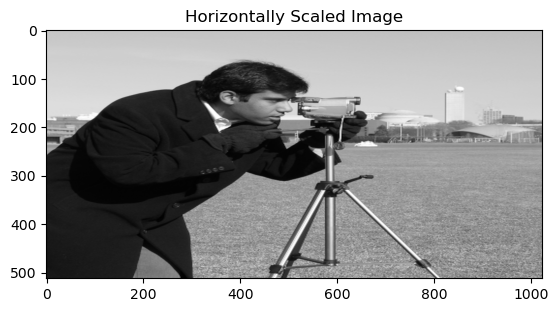

In [61]:
new_cx = width * cx
new_cy = height * cy

# non-uniform scale
non_uniform_scaled_image = img.resize((new_cx , new_cy) , Image.Resampling.LANCZOS)

plt.imshow(non_uniform_scaled_image , cmap = "gray")
plt.title("Horizontally Scaled Image")
plt.show()

In [62]:
non_uniform_scaled_image.save("non_uniform_scaled_image.jpg")

print("Original size:", img.size)
print("Scaled size:", non_uniform_scaled_image.size)

Original size: (512, 512)
Scaled size: (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

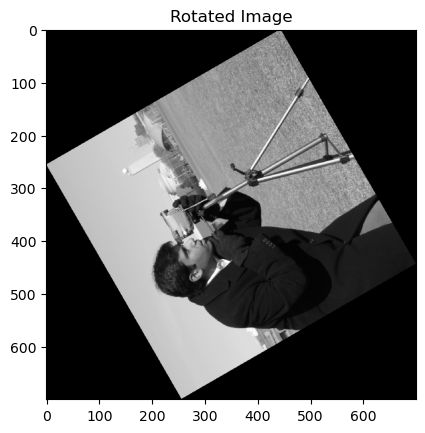

Original size: (512, 512)
Rotated size:  (700, 700)


In [63]:
# ── 2. Rotate 120 degrees 
rotated_image = img.rotate(120 , expand = True)

plt.imshow(rotated_image , cmap = "gray")
plt.title("Rotated Image")
plt.show()
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_image.save("task1_2_rotated.jpg")

print("Original size:", img.size)
print("Rotated size: " , rotated_image.size)

### 3. Shear

In [64]:
# -- c. Get the image dimensions 
width , height = img.size

In [65]:
# -- d. define the shear matrix 
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5

shear_matrix = (1 , -shear_factor , 0 , 0 , 1 , 0)

In [66]:
# -- e. Apply the shear transformation to the image 
# PIL's transform() takes the inverse affine matrix:
# transform(size, method, data)
# [ 1    shx   tx ]
# [ shy  1     ty ]

sheared_image = img.transform(img.size , Image.Transform.AFFINE , shear_matrix)

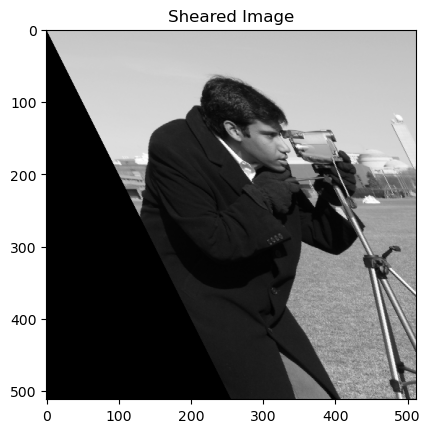

In [67]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_image.save("task1_3_sheared.jpg")

plt.imshow(sheared_image , cmap = "gray")
plt.title("Sheared Image")
plt.show()

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

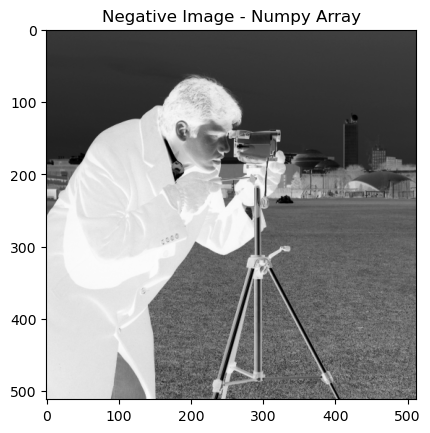

In [68]:
# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
array_img = np.array(img)
negative_array = 255 - array_img

negative_image = Image.fromarray(negative_array)

plt.imshow(negative_image , cmap = "gray")
plt.title("Negative Image - Numpy Array")
plt.show()

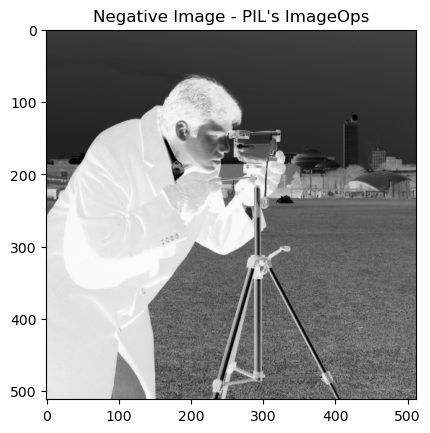

In [69]:
# Method 2: PIL's ImageOps
negative_image2 = ImageOps.invert(img)

plt.imshow(negative_image2 , cmap = "gray")
plt.title("Negative Image - PIL's ImageOps")
plt.show()

In [70]:
# ── 2. Log transformation 

# s = c · log(1 + r) --> We need to find c.
# r = original pixel value   s = transformed pixel value   c = scaling constant
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

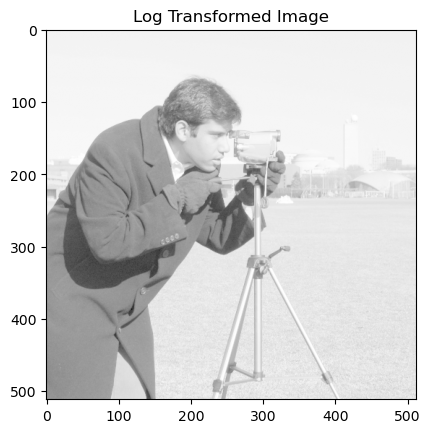

In [71]:
# Apply the log transformation to each pixel

c = 255 / np.log(1 + 255)
# Convert pixels to float to avoid uint8 overflow
array_float = np.array(img , dtype = np.float32)

log_transformed_array = c * np.log(1 + array_float)
log_transformed_image = Image.fromarray(np.uint8(log_transformed_array))
                                        
plt.imshow(log_transformed_image , cmap = "gray")
plt.title("Log Transformed Image")
plt.show()

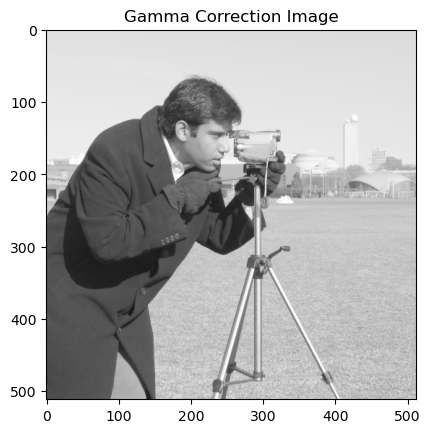

In [73]:
# ── 3. Power-law / Gamma correction: s = c * r^γ

# Normalize pixel values to 0–1
array_normalized = np.array(img , dtype = np.float32) / 255

gamma = 0.5
gamma_array = np.power(array_normalized , gamma)
gamma_array = gamma_array * 255 # Convert back to 0–255
gamma_image = Image.fromarray(np.uint8(gamma_array))

plt.imshow(gamma_image , cmap = "gray")
plt.title("Gamma Correction Image")
plt.show()